# Sold Weeks 2-3

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sold = pd.read_csv("../IDX_Data/sold_combined_residential.csv")
print("Shape:", sold.shape)
sold.head()

/var/folders/hx/s9px6scd2pl5dqfp0pldbdgc0000gn/T/ipykernel_49155/2762576175.py:5: DtypeWarning: Columns (0: BuyerAgentAOR, 1: ListAgentAOR, 2: WaterfrontYN, 3: ListAgentEmail, 4: FireplaceYN, 5: OriginatingSystemName, 6: OriginatingSystemSubName, 7: BuyerAgencyCompensationType, 8: latfilled, 9: lonfilled) have mixed types. Specify dtype option on import or set low_memory=False.
  sold = pd.read_csv("../IDX_Data/sold_combined_residential.csv")


Shape: (397172, 84)


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,OriginatingSystemName,OriginatingSystemSubName,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled
0,Mlslistings,Mlslistings,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,...,94401,6472.0,NaN,NaN,CRMLS,CRMLS_MLSL,NaN,NaN,NaN,NaN
1,SanDiego,SanDiego,NaN,False,NaN,NaN,False,759900.0,522107581,mdarwich12@gmail.com,...,91950,NaN,NaN,NaN,CRMLS,CRMLS_SAND,NaN,NaN,NaN,NaN
2,SanDiego,SanDiego,NaN,False,NaN,NaN,False,739900.0,510919001,mdarwich12@gmail.com,...,91950,NaN,NaN,NaN,CRMLS,CRMLS_SAND,NaN,NaN,NaN,NaN
3,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,NaN,1079166779,davidmartz@compass.com,...,92262,NaN,13504.0,NaN,CRMLS,CRMLS_MLSL,NaN,NaN,NaN,NaN
4,Southland,Southland,NaN,False,NaN,NaN,False,1890500.0,1075037759,karen.klein@theagencyre.com,...,91356,0.0,17873.0,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN


In [10]:
sold.columns

Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN',
       'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey',
       'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName',
       'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress',
       'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket',
       'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName',
       'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName',
       'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName',
       'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea',
       'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount',
       'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric',
       'ListingId', 'BathroomsTotalInteger', 'City', '

In [11]:
sold.info()

<class 'pandas.DataFrame'>
RangeIndex: 397172 entries, 0 to 397171
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   BuyerAgentAOR                 348119 non-null  str    
 1   ListAgentAOR                  350986 non-null  str    
 2   Flooring                      254757 non-null  str    
 3   ViewYN                        363353 non-null  object 
 4   WaterfrontYN                  248 non-null     object 
 5   BasementYN                    7769 non-null    object 
 6   PoolPrivateYN                 362758 non-null  object 
 7   OriginalListPrice             396458 non-null  float64
 8   ListingKey                    397172 non-null  int64  
 9   ListAgentEmail                368591 non-null  str    
 10  CloseDate                     397172 non-null  str    
 11  ClosePrice                    397170 non-null  float64
 12  ListAgentFirstName            394173 non-null  str    


In [14]:
missing = sold.isnull().sum()
missing_pct = (missing / len(sold)) * 100

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values(by='missing_pct', ascending=False)

missing_df.head(20)

,missing_count,missing_pct
CoveredSpaces,397172,100.000000
MiddleOrJuniorSchoolDistrict,397172,100.000000
AboveGradeFinishedArea,397172,100.000000
FireplacesTotal,397172,100.000000
TaxYear,397172,100.000000
ElementarySchoolDistrict,397172,100.000000
BusinessType,397172,100.000000
TaxAnnualAmount,397172,100.000000
WaterfrontYN,396924,99.937559
BelowGradeFinishedArea,394883,99.423675


In [ ]:
high_missing = missing_df[missing_df['missing_pct'] > 90]
print("Columns with >90% missing:")
high_missing

Columns with >90% missing:


,missing_count,missing_pct
CoveredSpaces,397172,100.000000
MiddleOrJuniorSchoolDistrict,397172,100.000000
AboveGradeFinishedArea,397172,100.000000
FireplacesTotal,397172,100.000000
TaxYear,397172,100.000000
ElementarySchoolDistrict,397172,100.000000
BusinessType,397172,100.000000
TaxAnnualAmount,397172,100.000000
WaterfrontYN,396924,99.937559
BelowGradeFinishedArea,394883,99.423675


In [20]:
cols_to_drop = missing_df[missing_df['missing_pct'] > 90].index.tolist()
print("Columns to drop later:")
cols_to_drop

Columns to drop later:


['CoveredSpaces',
 'MiddleOrJuniorSchoolDistrict',
 'AboveGradeFinishedArea',
 'FireplacesTotal',
 'TaxYear',
 'ElementarySchoolDistrict',
 'BusinessType',
 'TaxAnnualAmount',
 'WaterfrontYN',
 'BelowGradeFinishedArea',
 'BasementYN',
 'LotSizeDimensions',
 'BuilderName',
 'BuildingAreaTotal',
 'CoBuyerAgentFirstName',
 'OriginatingSystemName',
 'OriginatingSystemSubName']

In [24]:
numeric_cols = [
    'ClosePrice',
    'ListPrice',
    'OriginalListPrice',
    'LivingArea',
    'LotSizeAcres',
    'BedroomsTotal',
    'BathroomsTotalInteger',
    'DaysOnMarket',
    'YearBuilt'
]
sold[numeric_cols].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99])

,ClosePrice,ListPrice,OriginalListPrice,LivingArea,LotSizeAcres,BedroomsTotal,BathroomsTotalInteger,DaysOnMarket,YearBuilt
count,3.971700e+05,3.971720e+05,3.964580e+05,3.969440e+05,3.658650e+05,397161.000000,397103.000000,397172.000000,396816.000000
mean,1.186364e+06,1.138658e+06,1.224875e+06,1.904410e+03,6.839010e+01,3.200251,2.533141,37.321060,1978.561520
std,5.982775e+06,1.353854e+06,6.783315e+06,2.703243e+04,1.633495e+04,1.067483,1.136094,53.511051,26.267244
min,0.000000e+00,5.250000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,-288.000000,1776.000000
1%,2.020000e+05,2.149000e+05,2.100000e+05,6.040000e+02,0.000000e+00,1.000000,1.000000,0.000000,1912.000000
25%,5.750000e+05,5.754990e+05,5.850000e+05,1.247000e+03,1.200000e-01,3.000000,2.000000,8.000000,1960.000000
50%,8.200490e+05,8.150000e+05,8.250000e+05,1.641000e+03,1.663000e-01,3.000000,2.000000,19.000000,1979.000000
75%,1.300000e+06,1.295000e+06,1.299000e+06,2.217000e+03,2.723000e-01,4.000000,3.000000,48.000000,1999.000000
99%,5.550000e+06,5.695000e+06,5.995000e+06,5.280000e+03,1.079891e+01,6.000000,6.000000,229.000000,2025.000000
max,9.895000e+08,1.375000e+08,1.390000e+09,1.702132e+07,7.810698e+06,45.000000,175.000000,12430.000000,2026.000000


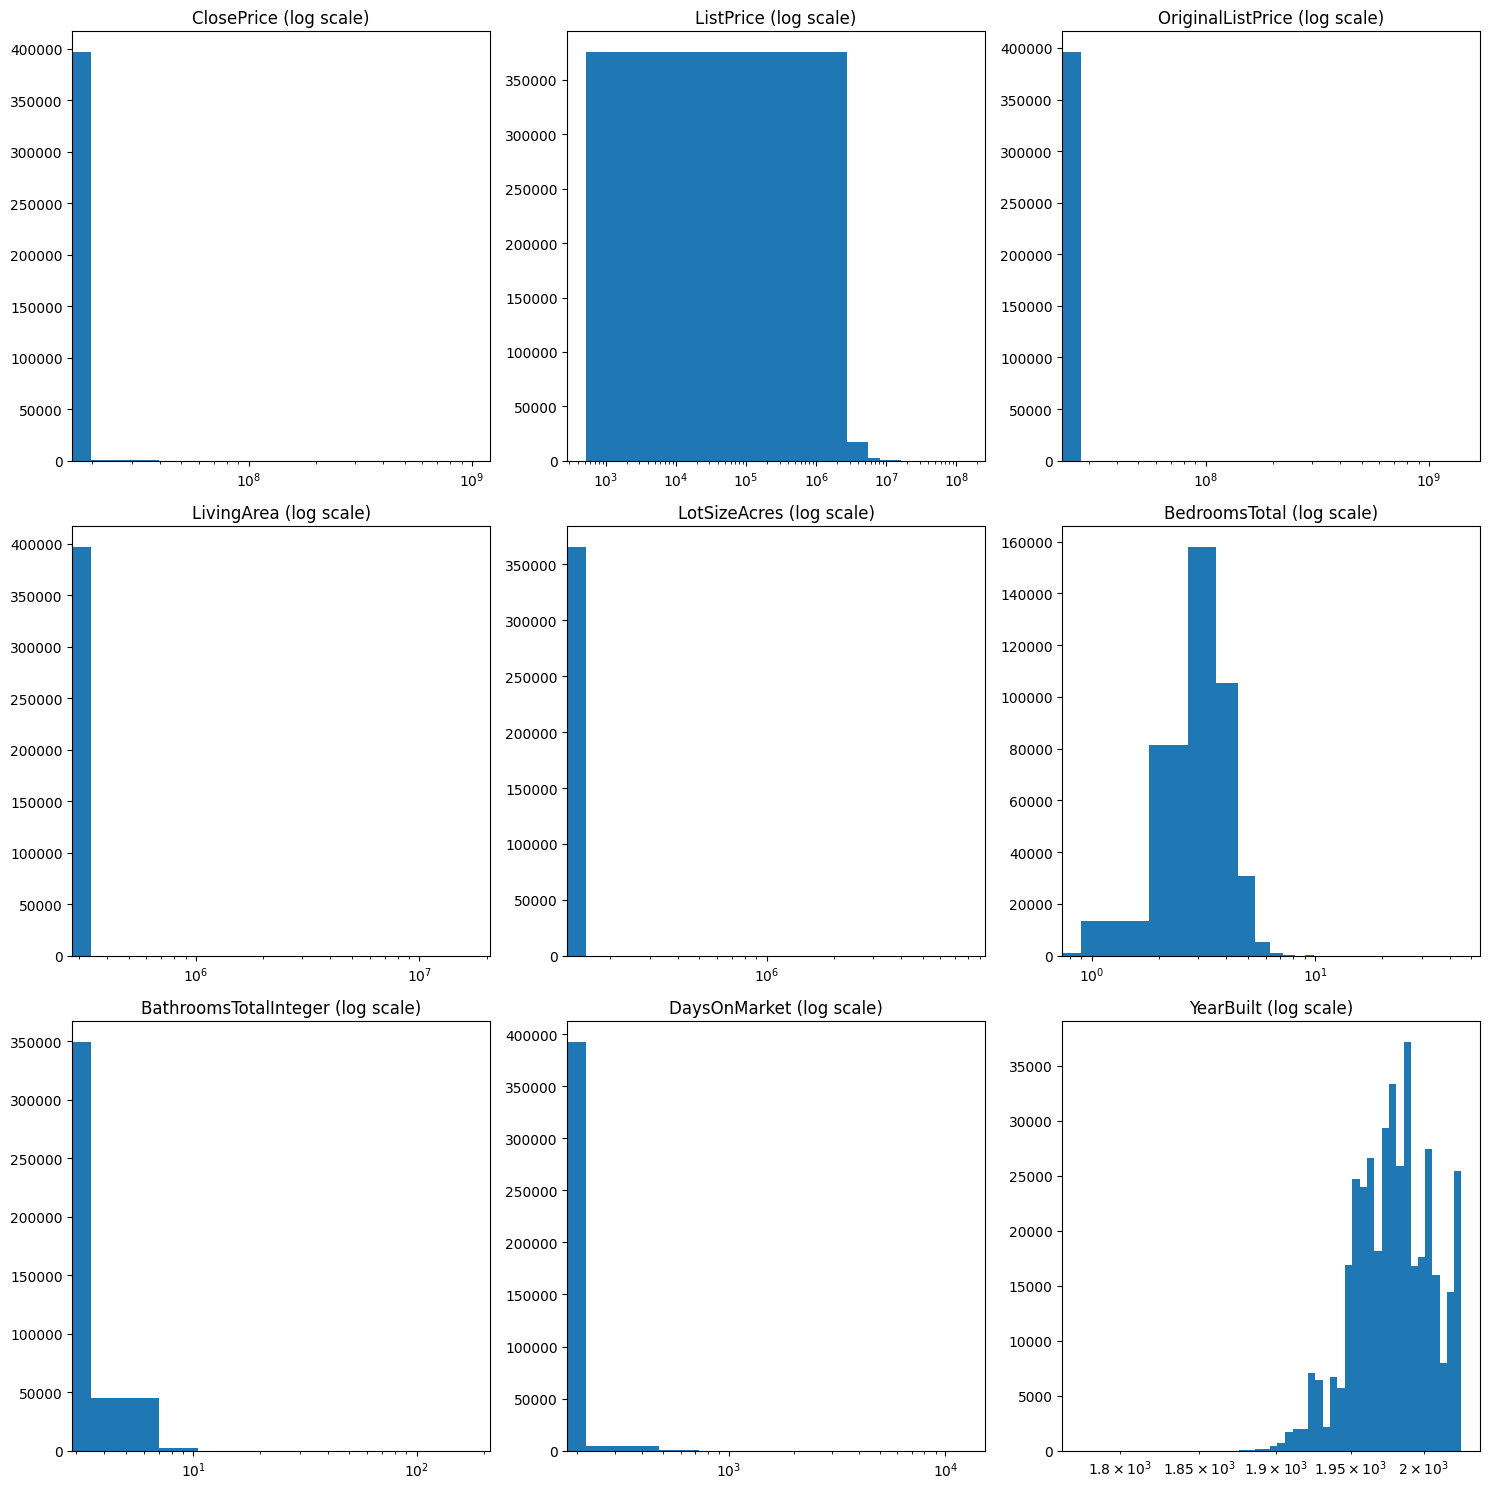

In [28]:
import math
n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    data = sold[col].dropna()
    
    axes[i].hist(data, bins=50)
    axes[i].set_title(f"{col} (log scale)")
    axes[i].set_xscale('log')

# remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

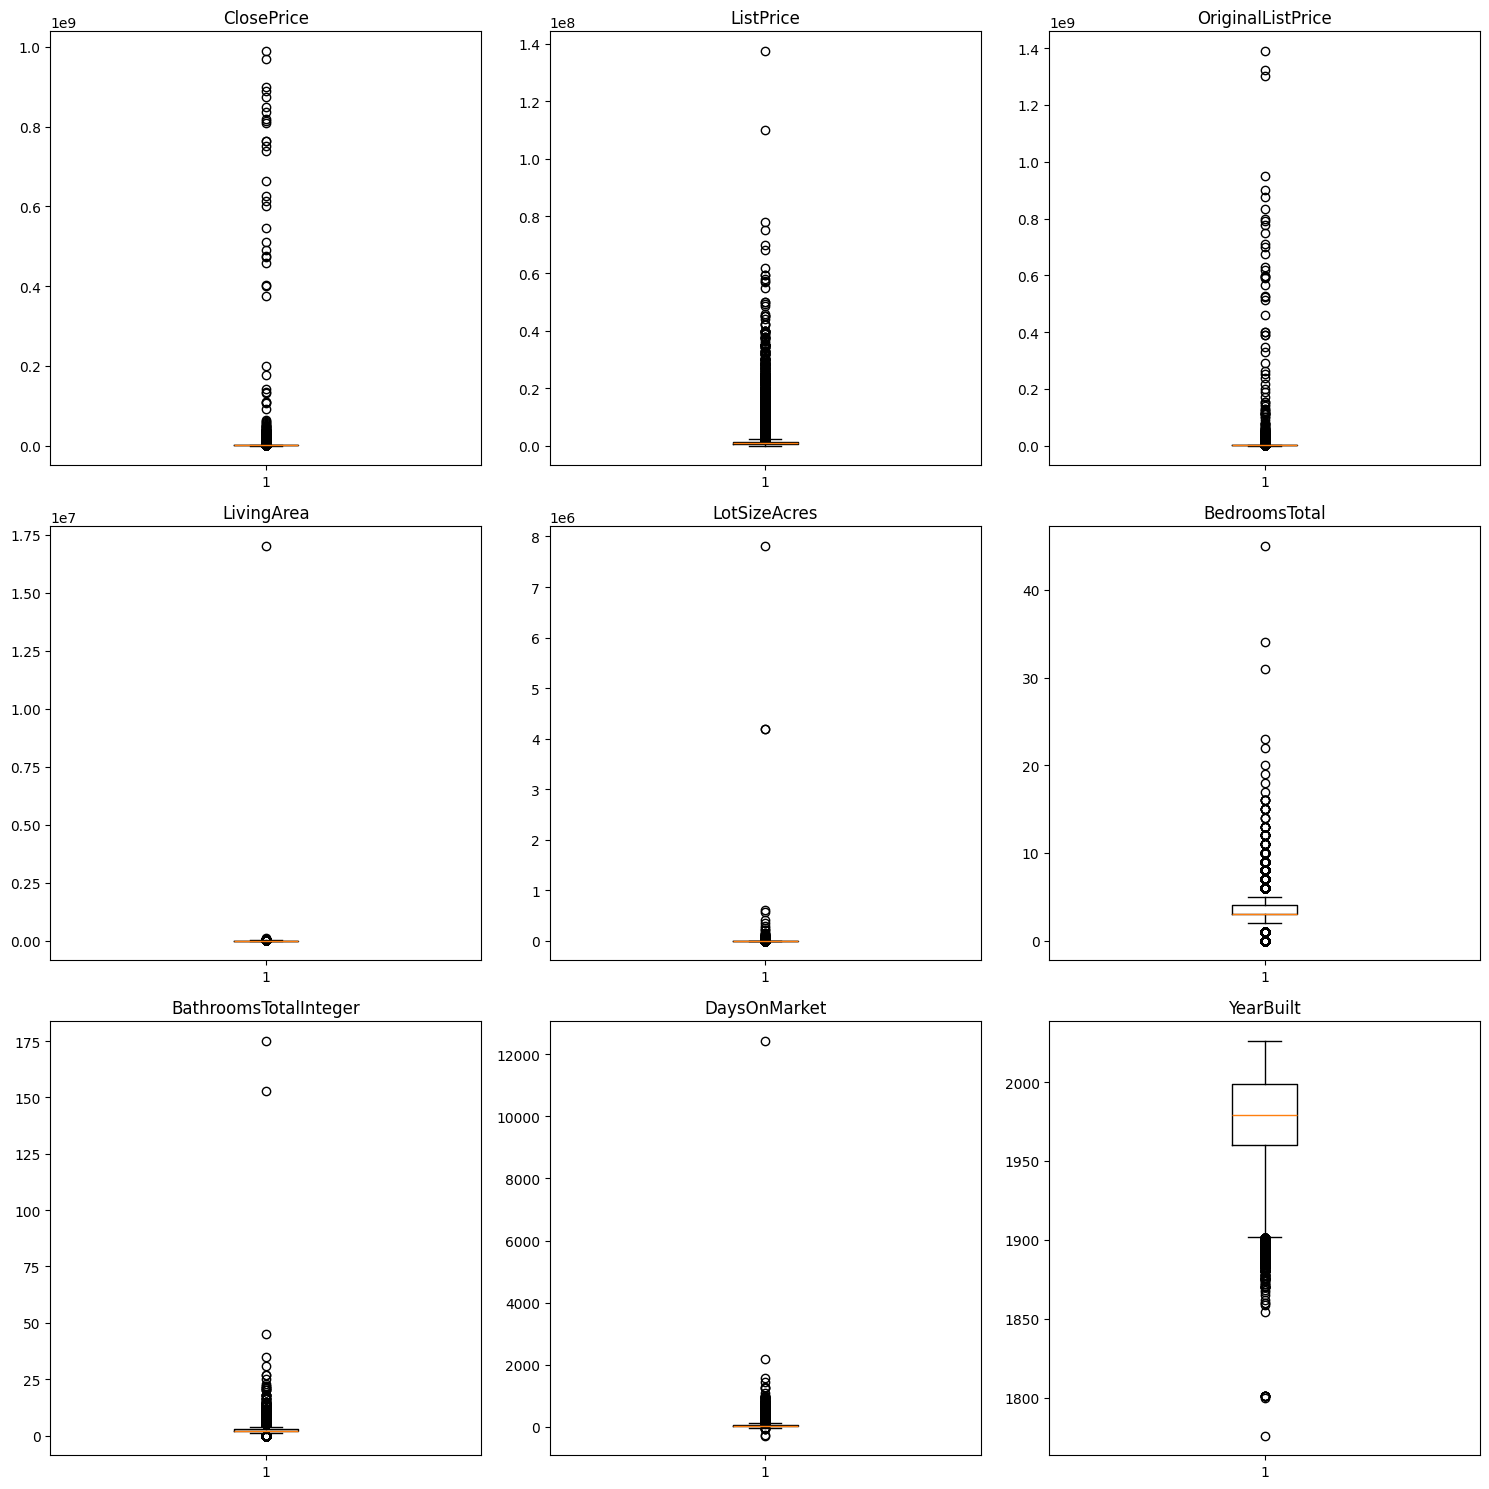

In [27]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(sold[col].dropna())
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [29]:
median_price = sold['ClosePrice'].median()
mean_price = sold['ClosePrice'].mean()

print("Median:", median_price)
print("Mean:", mean_price)

Median: 820049.0
Mean: 1186364.0407035023


In [30]:
above = (sold['ClosePrice'] > sold['ListPrice']).mean() * 100
below = (sold['ClosePrice'] < sold['ListPrice']).mean() * 100

print("Above list %:", above)
print("Below list %:", below)

Above list %: 40.116624535465746
Below list %: 42.544791677157505


In [31]:
sold['CloseDate'] = pd.to_datetime(sold['CloseDate'], errors='coerce')
sold['ListingContractDate'] = pd.to_datetime(sold['ListingContractDate'], errors='coerce')

invalid_dates = (sold['CloseDate'] < sold['ListingContractDate']).sum()

print("Invalid date cases:", invalid_dates)

Invalid date cases: 58


In [32]:
county_prices = (
    sold.groupby('CountyOrParish')['ClosePrice']
    .median()
    .sort_values(ascending=False)
)
county_prices.head(10)

CountyOrParish
Del Norte        2485000.0
Other County     2462500.0
San Mateo        1700000.0
Santa Clara      1600000.0
Santa Cruz       1200000.0
San Francisco    1180000.0
Orange           1175000.0
Marin            1170000.0
Alameda          1135000.0
Alpine           1100000.0
Name: ClosePrice, dtype: float64

# Deliverables 

In [33]:
sold['PropertyType'].unique()

<StringArray>
['Residential']
Length: 1, dtype: str

In [34]:
sold = sold[sold['PropertyType'] == 'Residential']
print("Shape after Residential filter:", sold.shape)

Shape after Residential filter: (397172, 84)


In [35]:
null_counts = sold.isnull().sum()
null_counts.sort_values(ascending=False).head(20)

CoveredSpaces                   397172
MiddleOrJuniorSchoolDistrict    397172
AboveGradeFinishedArea          397172
FireplacesTotal                 397172
TaxYear                         397172
ElementarySchoolDistrict        397172
BusinessType                    397172
TaxAnnualAmount                 397172
WaterfrontYN                    396924
BelowGradeFinishedArea          394883
BasementYN                      389403
LotSizeDimensions               377873
BuilderName                     377666
BuildingAreaTotal               369423
CoBuyerAgentFirstName           361189
OriginatingSystemName           358351
OriginatingSystemSubName        358351
BuyerAgencyCompensation         351047
BuyerAgencyCompensationType     351036
ElementarySchool                344221
dtype: int64

In [37]:
print("Columns with >90% missing:")
high_missing

Columns with >90% missing:


,missing_count,missing_pct
CoveredSpaces,397172,100.000000
MiddleOrJuniorSchoolDistrict,397172,100.000000
AboveGradeFinishedArea,397172,100.000000
FireplacesTotal,397172,100.000000
TaxYear,397172,100.000000
ElementarySchoolDistrict,397172,100.000000
BusinessType,397172,100.000000
TaxAnnualAmount,397172,100.000000
WaterfrontYN,396924,99.937559
BelowGradeFinishedArea,394883,99.423675


In [36]:
sold[['ClosePrice', 'LivingArea', 'DaysOnMarket']].describe(
    percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]
)

,ClosePrice,LivingArea,DaysOnMarket
count,3.971700e+05,3.969440e+05,397172.000000
mean,1.186364e+06,1.904410e+03,37.321060
std,5.982775e+06,2.703243e+04,53.511051
min,0.000000e+00,0.000000e+00,-288.000000
1%,2.020000e+05,6.040000e+02,0.000000
5%,3.400000e+05,8.390000e+02,1.000000
50%,8.200490e+05,1.641000e+03,19.000000
95%,2.850000e+06,3.558000e+03,131.000000
99%,5.550000e+06,5.280000e+03,229.000000
max,9.895000e+08,1.702132e+07,12430.000000


In [38]:
sold.to_csv("sold_filtered_week2_3.csv", index=False)
print("Saved filtered dataset.")

Saved filtered dataset.
